C:\Users\schur\AppData\Local\Temp\ipykernel_13456\1424262690.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_transformed = df_transformed.replace(mapdict)


Mean Absolute Error: 595.83 KG CO2 per jaar
De b0 waarde van de formule is: 2679.056043024899
De coëfficiënten van de formule zijn: [  46.02188821    9.37832071   18.54525045   16.71966707   13.90323402
    6.50448428 3116.87368199   35.79166552  137.76773423  187.16241324
  115.65564022  158.95541056  -53.14965874   77.13171176  -67.64966611
 2599.89476464   40.9688211    77.69328496  230.85601324  198.33967934
   75.0686327   162.86864699  232.95414395   40.45724353  195.27986144
  126.68257171  114.67147673  -26.45027937   -8.92662444 -105.93020837
  -36.73338153   18.82901898]
Voorspelling: 2992.72 KG CO2 per jaar


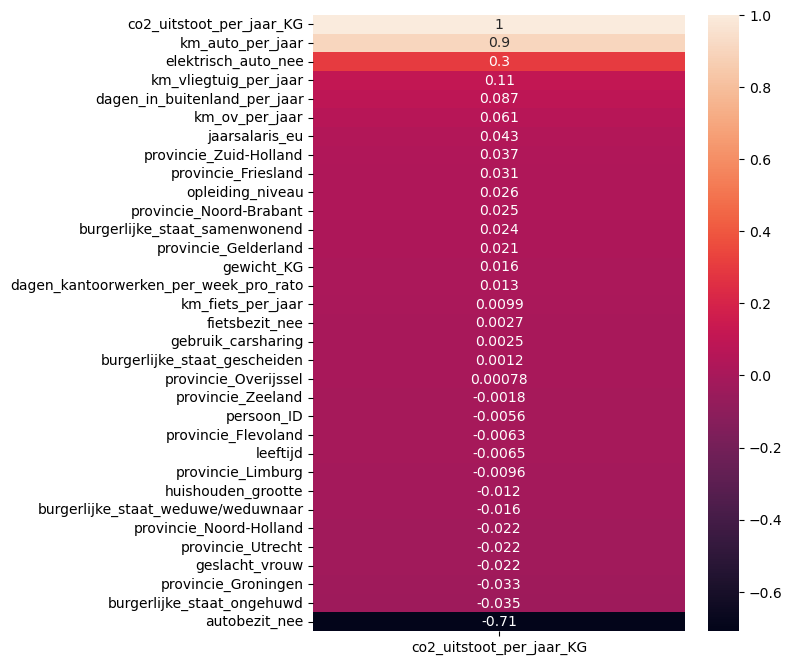

Cross-validated MAE scores: [603.01477026 727.69362885 666.70501477 720.49482372 683.46839693
 728.41047931 820.80483071 535.39785898 804.77500585 596.13230617
 563.09575888 638.12839913 675.47735515 577.77955791 665.9995805
 720.42730155 755.28734275 735.98904232 770.461312   734.30788204]
Cross-validated MAE scores voor top 5 features: [572.81212509 760.12551022 696.89834606 726.38031071 686.17901458
 714.30135978 833.63470104 553.15161297 782.36953082 602.62965873
 567.00591858 640.51707876 676.68641085 598.32376238 657.13250059
 699.67566794 722.97089224 727.64508985 778.52585464 743.46319266]


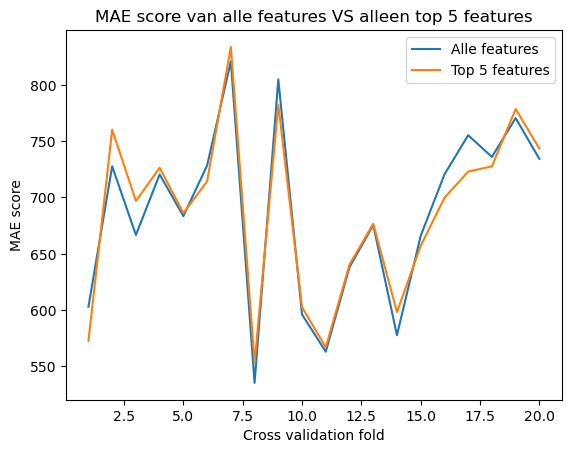

Toets: paired t-test, p = 0.8414
Gemiddelde score Model 1: 686.1925
Gemiddelde score Model 2: 687.0214


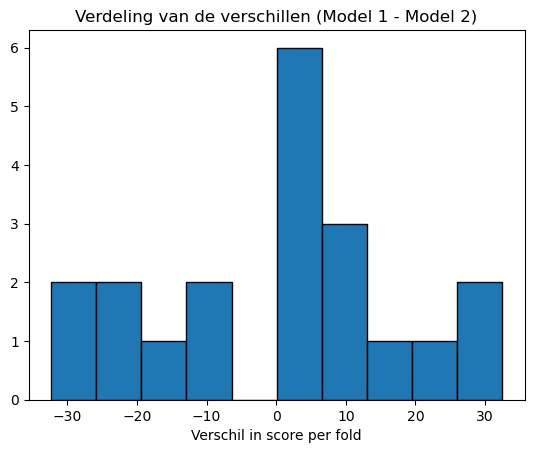

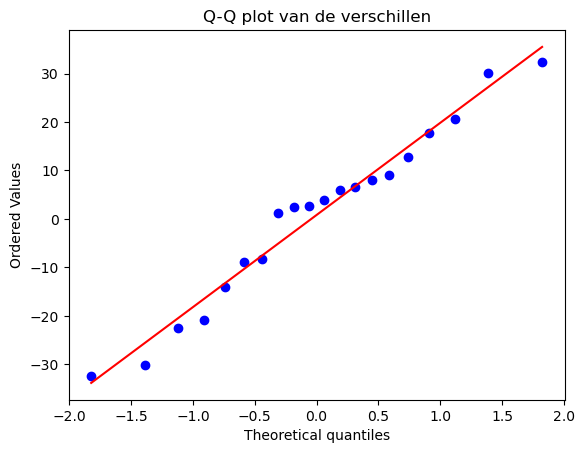

Accuracy: 0.9366666666666666
              precision    recall  f1-score   support

        laag       0.82      0.97      0.89        77
        hoog       0.99      0.92      0.96       223

    accuracy                           0.94       300
   macro avg       0.90      0.95      0.92       300
weighted avg       0.95      0.94      0.94       300



In [2]:
%run Wiskunde_II_Portfolio.ipynb

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [4]:
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 200)

In [5]:
df_transformed

,persoon_ID,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,opleiding_niveau,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,gebruik_carsharing,co2_uitstoot_per_jaar_KG,autobezit_nee,fietsbezit_nee,elektrisch_auto_nee,geslacht_vrouw,provincie_Flevoland,provincie_Friesland,provincie_Gelderland,provincie_Groningen,provincie_Limburg,provincie_Noord-Brabant,provincie_Noord-Holland,provincie_Overijssel,provincie_Utrecht,provincie_Zeeland,provincie_Zuid-Holland,burgerlijke_staat_gescheiden,burgerlijke_staat_ongehuwd,burgerlijke_staat_samenwonend,burgerlijke_staat_weduwe/weduwnaar,co2_label
0,811069,50,52.66,48003.64,5,1,13266.05,2040.54,3227.95,480.71,1,20,1,7591.93,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,1
1,246882,65,64.58,55208.63,2,3,15229.89,0.00,2298.96,1423.34,0,7,2,8742.25,False,True,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,1
2,978385,49,90.87,29533.78,2,2,19853.24,1540.46,4504.21,632.48,1,2,5,4513.56,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,1
3,120468,34,80.43,44453.27,2,2,9935.50,1825.92,4407.56,1266.84,2,21,2,6904.41,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,1
4,637034,60,72.28,56497.64,2,1,16266.67,1851.07,1936.12,1676.00,5,0,1,4420.80,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,838823,78,85.84,28295.50,1,2,6383.24,3672.70,3085.83,1254.60,0,11,2,4251.29,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,1
1496,964501,54,85.09,45963.45,5,1,18050.72,1907.56,1247.67,907.07,1,3,2,4615.63,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,1
1497,659695,48,71.79,43443.92,5,2,6860.47,1568.27,1051.74,1385.12,0,13,1,4631.48,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,1
1498,883394,76,69.02,33158.29,4,1,0.00,2170.89,1978.18,364.76,0,15,1,786.82,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0


In [6]:
df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 34 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   persoon_ID                             1500 non-null   int64  
 1   leeftijd                               1500 non-null   int64  
 2   gewicht_KG                             1500 non-null   float64
 3   jaarsalaris_eu                         1500 non-null   float64
 4   huishouden_grootte                     1500 non-null   int64  
 5   opleiding_niveau                       1500 non-null   int64  
 6   km_auto_per_jaar                       1500 non-null   float64
 7   km_fiets_per_jaar                      1500 non-null   float64
 8   km_ov_per_jaar                         1500 non-null   float64
 9   km_vliegtuig_per_jaar                  1500 non-null   float64
 10  dagen_kantoorwerken_per_week_pro_rato  1500 non-null   int64  
 11  dage

In [7]:
#feature_eng_cols = ['km_totaal', 'aandeel_auto', 'aandeel_vliegtuig', 'kantoor_dagen_per_jaar', 'hoog_uitstoot_gedrag']

#raw_eng_cols = ['km_auto_per_jaar', 'km_fiets_per_jaar', 'km_ov_per_jaar', 'km_vliegtuig_per_jaar', 'dagen_kantoorwerken_per_week_pro_rato']

#df_transformed = df_transformed.drop(raw_eng_cols, axis=1)

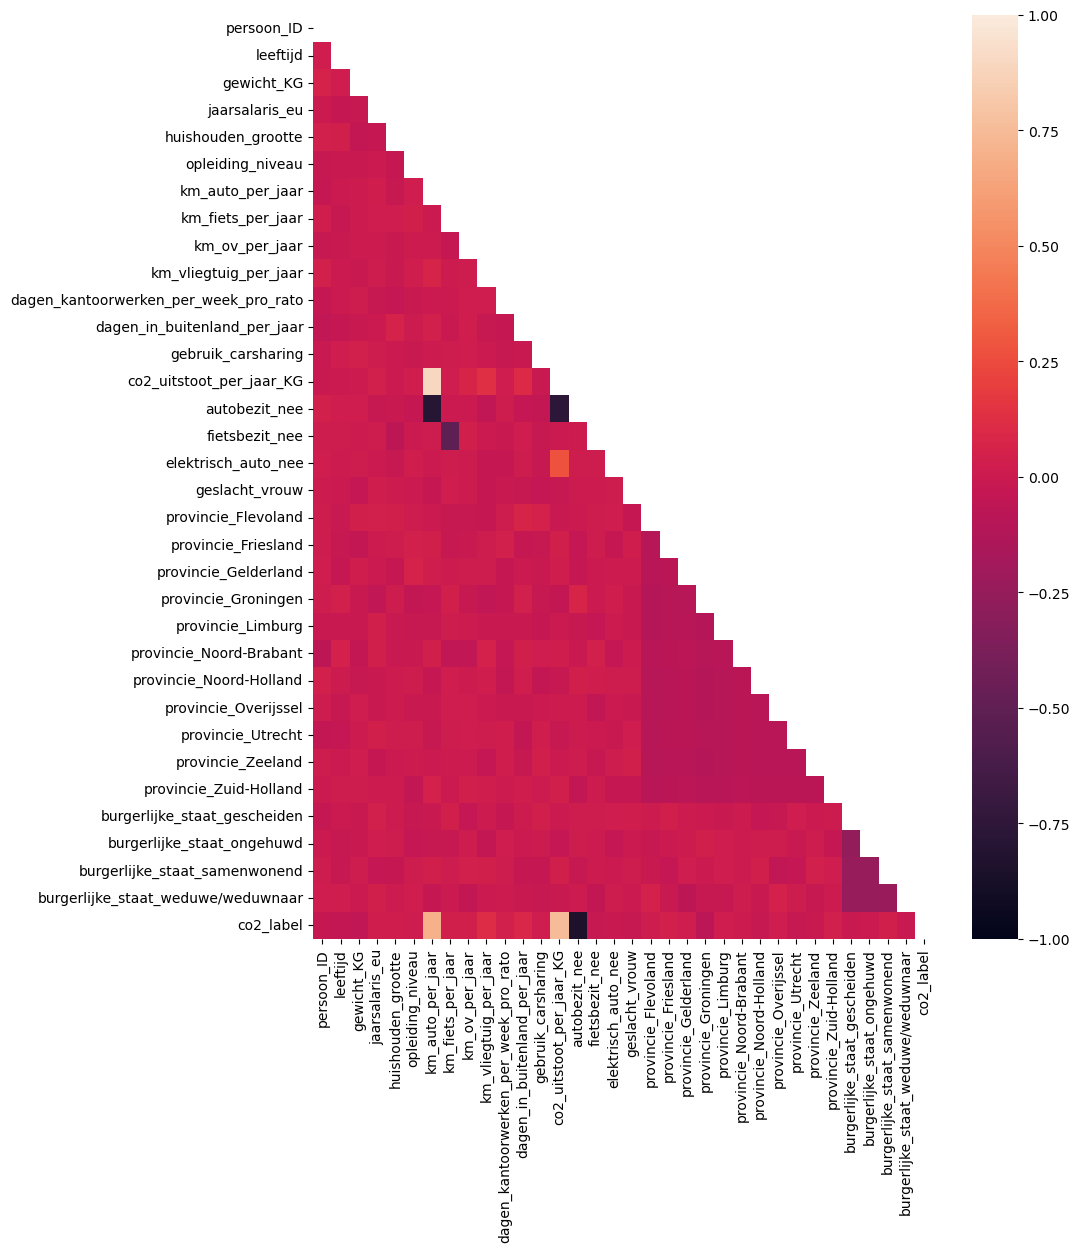

In [8]:
plt.figure(figsize=(10, 12))

corr = df_transformed.corr(method='spearman')
mask= np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, vmin=-1, vmax=1)

plt.show()

In [9]:
df[modus_cols]


,geslacht,burgerlijke_staat,provincie,opleiding_niveau,autobezit,fietsbezit,elektrisch_auto,gebruik_carsharing
0,man,weduwe/weduwnaar,Flevoland,MBO,ja,ja,nee,Nooit
1,vrouw,samenwonend,Overijssel,WO,ja,nee,nee,Heel soms
2,man,samenwonend,Utrecht,HBO,ja,ja,ja,Altijd
3,man,gehuwd,Utrecht,HBO,ja,ja,nee,Heel soms
4,man,ongehuwd,Gelderland,MBO,ja,ja,ja,Nooit
...,...,...,...,...,...,...,...,...
1495,man,weduwe/weduwnaar,Noord-Holland,HBO,ja,ja,nee,Heel soms
1496,man,ongehuwd,Drenthe,MBO,ja,ja,ja,Heel soms
1497,man,weduwe/weduwnaar,Flevoland,HBO,ja,ja,nee,Nooit
1498,man,gehuwd,Drenthe,MBO,nee,ja,nee,Nooit


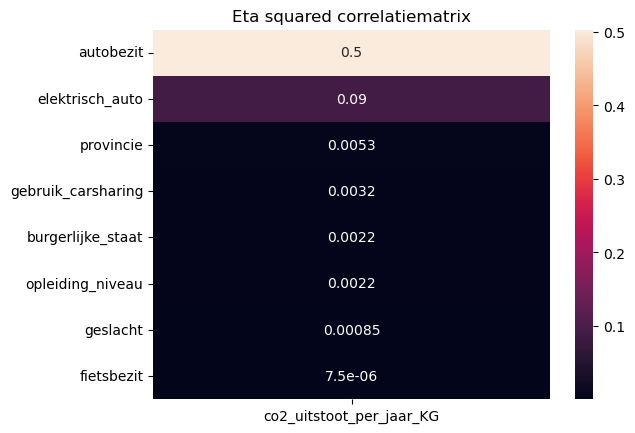

In [10]:
import numpy as np

modus_cols = ['geslacht', 'burgerlijke_staat', 'provincie', 'opleiding_niveau', 'autobezit', 'fietsbezit', 'elektrisch_auto', 'gebruik_carsharing']

def eta_squared(categorisch, numeriek):
    groepen = [numeriek[categorisch == c] for c in categorisch.unique()]
    grand_mean = numeriek.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groepen)
    ss_total = ((numeriek - grand_mean)**2).sum()
    return ss_between / ss_total


corrdict = {}
for i in modus_cols:
    corrdict[i] = eta_squared(df[i], df['co2_uitstoot_per_jaar_KG'])
    
sns.heatmap(pd.DataFrame(pd.Series(corrdict).sort_values(ascending=False), 
                         columns=['co2_uitstoot_per_jaar_KG']), 
                         annot=True)

plt.title('Eta squared correlatiematrix')
plt.show()

<Axes: >

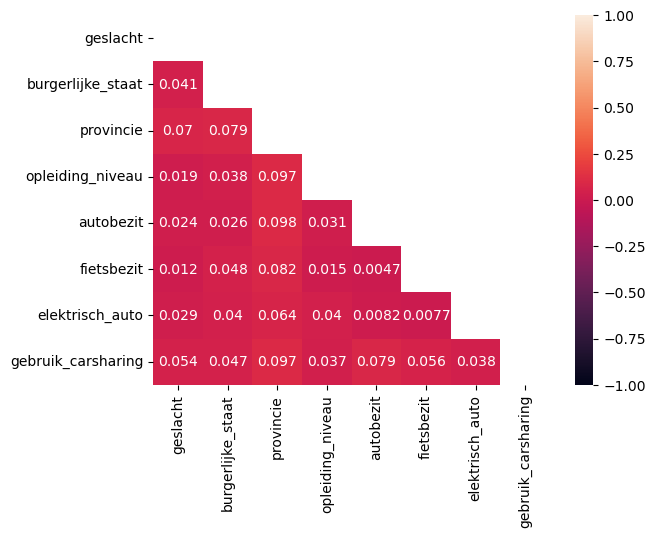

In [11]:
from scipy import stats
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.values.sum()
    r, k = confusion.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

dicto = {}

for i in modus_cols:
    dicto[i] = {}


    for j in modus_cols:

        dicto[i][j] = cramers_v(df[i], df[j])
        

        

dicto = pd.DataFrame(dicto)
mask = np.triu(np.ones_like(dicto))

sns.heatmap(dicto, annot=True, mask=mask, vmin=-1, vmax=1)

In [12]:
corr_target

,co2_uitstoot_per_jaar_KG
co2_uitstoot_per_jaar_KG,1.000000
km_auto_per_jaar,0.903283
elektrisch_auto_nee,0.300314
km_vliegtuig_per_jaar,0.105816
dagen_in_buitenland_per_jaar,0.087038
km_ov_per_jaar,0.060919
jaarsalaris_eu,0.042682
provincie_Zuid-Holland,0.037344
provincie_Friesland,0.031346
opleiding_niveau,0.025809


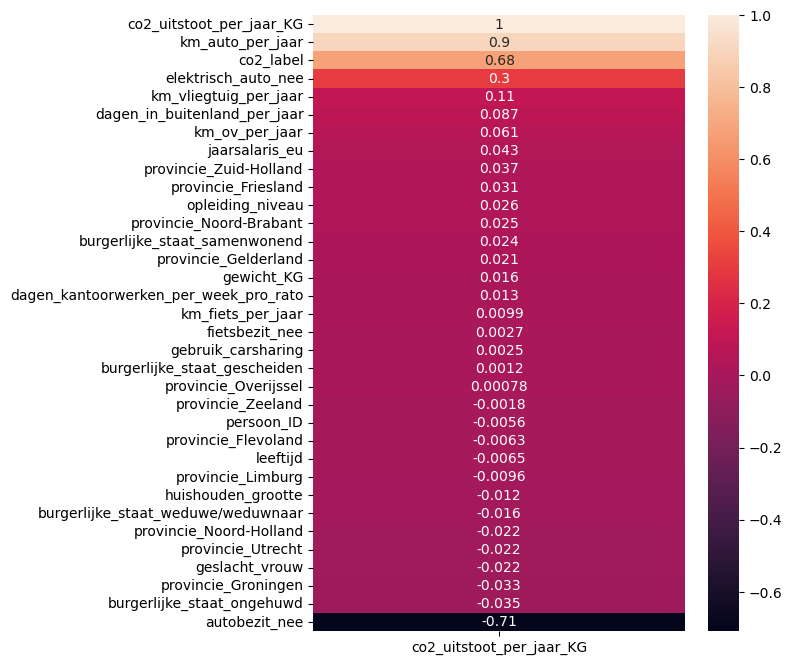

In [13]:
corr_target = df_transformed.corrwith(df_transformed['co2_uitstoot_per_jaar_KG']).sort_values(ascending=False).to_frame(name='co2_uitstoot_per_jaar_KG')

plt.figure(figsize=(6, 8))
sns.heatmap(corr_target, annot=True)

plt.show()

In [14]:
X = df_transformed.drop(['co2_uitstoot_per_jaar_KG', 'persoon_ID'], axis=1)
y = df_transformed['co2_uitstoot_per_jaar_KG']


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)







In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor



In [16]:
numerieke_cols = X_train.select_dtypes(exclude='bool').columns

scaler = StandardScaler()

X_train[numerieke_cols] = scaler.fit_transform(X_train[numerieke_cols])

X_test[numerieke_cols] = scaler.transform(X_test[numerieke_cols])


In [17]:
model = RandomForestRegressor()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

model.score(X_test, y_test)

0.9726879284804566

In [18]:
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

model.score(X_test, y_test)

0.9350568031794931

In [19]:
y_pred = model.predict(X_test)
score = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {score:.2f} KG CO2 per jaar")



print(f"De b0 waarde van de formule is: {model.intercept_}")
print(f"De coëfficiënten van de formule zijn: {model.coef_}")

Mean Absolute Error: 589.61 KG CO2 per jaar
De b0 waarde van de formule is: 2423.0167986240767
De coëfficiënten van de formule zijn: [  22.93800324   38.82109701   23.9772095     4.52344458   13.12159654
 3076.83790606   10.14021884  122.97810426  149.75467449   89.54659739
  122.40669872  -50.53736733 1083.09733628  -93.81155779 2620.53365389
   75.06389166   40.05566406  156.98076908  137.63449503   64.56968373
  116.05001243  213.50862684  -20.81879124   97.67530539  106.46906102
   91.45750166  -60.37061493  -33.26247743 -148.54218116 -105.67999408
  -15.58005946  582.24738349]


In [20]:
model.coef_

array([  22.93800324,   38.82109701,   23.9772095 ,    4.52344458,
         13.12159654, 3076.83790606,   10.14021884,  122.97810426,
        149.75467449,   89.54659739,  122.40669872,  -50.53736733,
       1083.09733628,  -93.81155779, 2620.53365389,   75.06389166,
         40.05566406,  156.98076908,  137.63449503,   64.56968373,
        116.05001243,  213.50862684,  -20.81879124,   97.67530539,
        106.46906102,   91.45750166,  -60.37061493,  -33.26247743,
       -148.54218116, -105.67999408,  -15.58005946,  582.24738349])

(array([445., 181., 220., 239., 220., 123.,  52.,  15.,   4.,   1.]),
 array([    0.   ,  1809.844,  3619.688,  5429.532,  7239.376,  9049.22 ,
        10859.064, 12668.908, 14478.752, 16288.596, 18098.44 ]),
 <BarContainer object of 10 artists>)

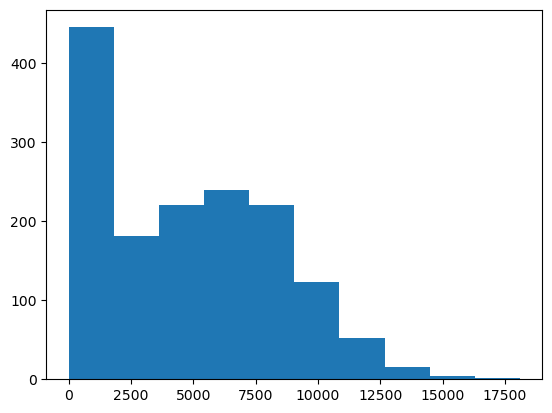

In [21]:
plt.hist(df_transformed.co2_uitstoot_per_jaar_KG)

In [22]:
mu = df['co2_uitstoot_per_jaar_KG'].mean()
sigma = df['co2_uitstoot_per_jaar_KG'].std()

z = (5000 - mu) / sigma

kans = 1- stats.norm.cdf(z) 

kans

np.float64(0.48963256070214634)

verdeling autobezit

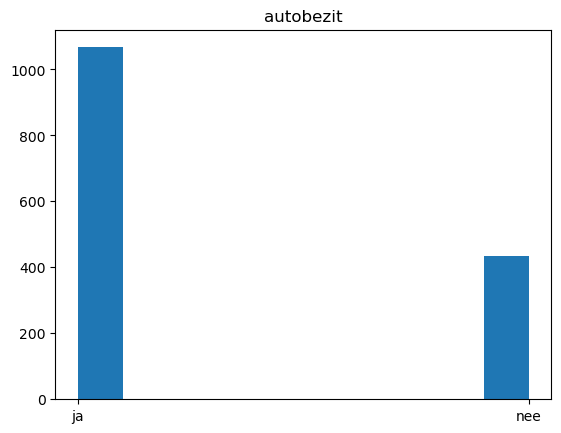

In [23]:
plt.hist(df['autobezit'])
plt.title('autobezit')
plt.show()

In [24]:
df_transformed

,persoon_ID,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,opleiding_niveau,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,gebruik_carsharing,co2_uitstoot_per_jaar_KG,autobezit_nee,fietsbezit_nee,elektrisch_auto_nee,geslacht_vrouw,provincie_Flevoland,provincie_Friesland,provincie_Gelderland,provincie_Groningen,provincie_Limburg,provincie_Noord-Brabant,provincie_Noord-Holland,provincie_Overijssel,provincie_Utrecht,provincie_Zeeland,provincie_Zuid-Holland,burgerlijke_staat_gescheiden,burgerlijke_staat_ongehuwd,burgerlijke_staat_samenwonend,burgerlijke_staat_weduwe/weduwnaar,co2_label
0,811069,50,52.66,48003.64,5,1,13266.05,2040.54,3227.95,480.71,1,20,1,7591.93,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,1
1,246882,65,64.58,55208.63,2,3,15229.89,0.00,2298.96,1423.34,0,7,2,8742.25,False,True,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,1
2,978385,49,90.87,29533.78,2,2,19853.24,1540.46,4504.21,632.48,1,2,5,4513.56,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,1
3,120468,34,80.43,44453.27,2,2,9935.50,1825.92,4407.56,1266.84,2,21,2,6904.41,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,1
4,637034,60,72.28,56497.64,2,1,16266.67,1851.07,1936.12,1676.00,5,0,1,4420.80,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,838823,78,85.84,28295.50,1,2,6383.24,3672.70,3085.83,1254.60,0,11,2,4251.29,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,1
1496,964501,54,85.09,45963.45,5,1,18050.72,1907.56,1247.67,907.07,1,3,2,4615.63,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,1
1497,659695,48,71.79,43443.92,5,2,6860.47,1568.27,1051.74,1385.12,0,13,1,4631.48,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,1
1498,883394,76,69.02,33158.29,4,1,0.00,2170.89,1978.18,364.76,0,15,1,786.82,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0


In [25]:
from scipy.stats import mannwhitneyu

groep1 = df_transformed[df_transformed['autobezit_nee'] == False]
groep2 = df_transformed[df_transformed['autobezit_nee'] == True]


stat, p = mannwhitneyu(groep1['co2_uitstoot_per_jaar_KG'], groep2['co2_uitstoot_per_jaar_KG'])

print(stat, p)


455357.0 2.0054594237707127e-191


In [35]:
df.autobezit


0        ja
1        ja
2        ja
3        ja
4        ja
       ... 
1495     ja
1496     ja
1497     ja
1498    nee
1499     ja
Name: autobezit, Length: 1500, dtype: object

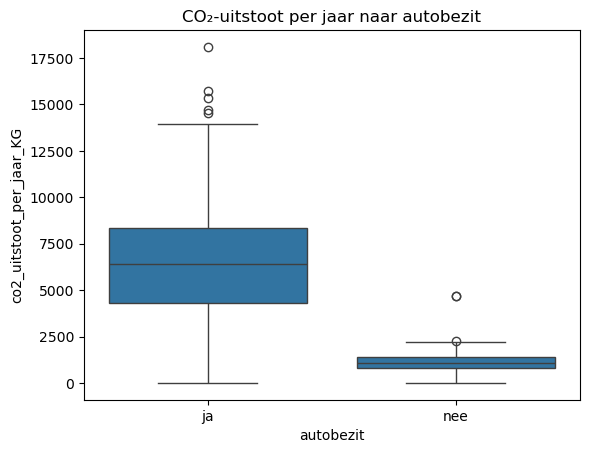

In [48]:
sns.boxplot(data=df, x='autobezit', y='co2_uitstoot_per_jaar_KG')
plt.title('CO₂-uitstoot per jaar naar autobezit')
plt.show()

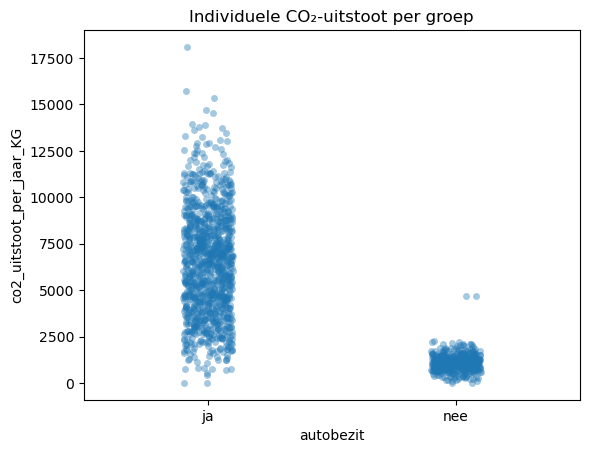

In [46]:
sns.stripplot(data=df, x='autobezit', y='co2_uitstoot_per_jaar_KG', 
              alpha=0.4, jitter=True)
plt.title('Individuele CO₂-uitstoot per groep')
plt.show()